In [1]:
from zedstat import zedstat

In [2]:
import pandas as pd
data_path = './PROBLEMATIC_LR_CURVE.parquet'
score_col = 'predicted_risk'
label_col = 'target'
deployment_prevalence = 0.05
use_convexify = False
lr_fpr_floor = 0.001

df = pd.read_parquet(data_path)
df = df[[score_col, label_col]].dropna().copy()
df.head()

,predicted_risk,target
0,0.054293,0
1,0.005538,0
2,0.010080,0
3,0.017941,0
4,0.010448,0


In [3]:
rf, total_samples, positive_samples = zedstat.genroc(
    df,
    risk="predicted_risk",
    target="target",
)

zt = zedstat.processRoc(
    rf,
    prevalence=deployment_prevalence,
    total_samples=total_samples,
    positive_samples=positive_samples,
    alpha=0.05,
    lr_fpr_floor=0.001,
)
zt.smooth(STEP=0.01, convexify=False)
zt.allmeasures(interpolate=True)
zt.usample(precision=3, recompute_measures=True)
zt.getBounds(
    ppv_ci_method="direct",
    min_expected_flags=10.0,
    min_expected_fp=5.0,
    min_expected_tn=5.0,
    enforce_bounds=True,
    smooth_ppv_bounds=True,
    mask_dominated_lr=True,
    lr_min_plus=1.001,
)

perf_df = (
    zt.get()
    .join(zt.df_lim["U"], rsuffix="_upper")
    .join(zt.df_lim["L"], rsuffix="_lower")
)

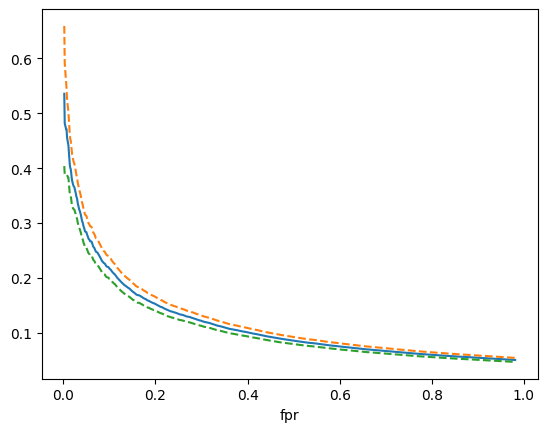

In [4]:
ax=perf_df.dropna().ppv.plot()
ax=perf_df.dropna().ppv_upper.plot(style='--')
ax=perf_df.dropna().ppv_lower.plot(style='--')


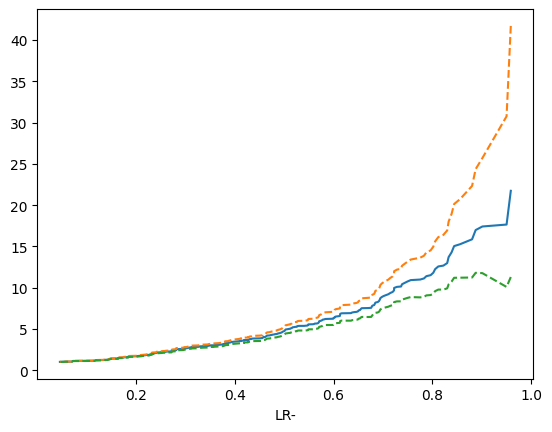

In [5]:
ax=perf_df.set_index('LR-').dropna()['LR+'].plot()
ax=perf_df.set_index('LR-').dropna()['LR+_upper'].plot(style='--')
ax=perf_df.set_index('LR-').dropna()['LR+_lower'].plot(style='--')


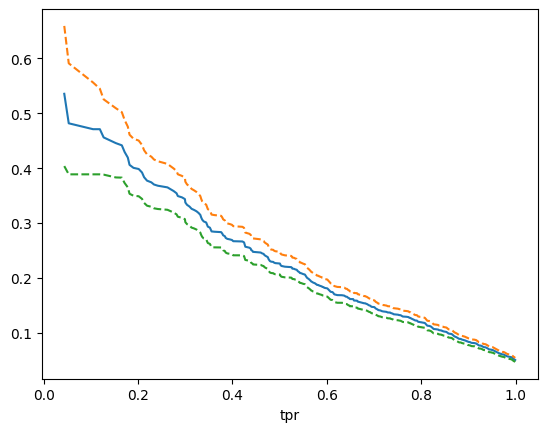

In [6]:
ax=perf_df.set_index('tpr').dropna().ppv.plot()
ax=perf_df.set_index('tpr').dropna().ppv_upper.plot(style='--')
ax=perf_df.set_index('tpr').dropna().ppv_lower.plot(style='--')


In [8]:
perf_df.dropna().head(12)

,tpr,ppv,acc,npv,LR+,LR-,threshold,expected_fp,expected_tn,expected_flags,...,tpr_lower,ppv_lower,acc_lower,npv_lower,LR+_lower,LR-_lower,threshold_lower,expected_fp_lower,expected_tn_lower,expected_flags_lower
fpr,,,,,,,,,,,,,,,,,,,,,
0.002,0.043488,0.535333,0.950274,0.951979,21.741851,0.958429,0.164391,26.068,13007.932,57.722085,...,0.033076,0.403744,0.948873,0.951438,11.296875,0.944304,0.164391,26.068,13007.932,57.722085
0.003,0.052957,0.481622,0.949798,0.952386,17.653287,0.949893,0.156740,39.102,12994.898,77.887865,...,0.041362,0.388732,0.948176,0.951781,10.097241,0.934480,0.156740,39.102,12994.898,77.887865
0.006,0.104508,0.470908,0.949525,0.954731,17.417917,0.900897,0.132059,78.204,12955.796,154.780414,...,0.088012,0.388732,0.947295,0.953870,11.767513,0.880559,0.132059,78.204,12955.796,154.780414
0.007,0.118900,0.470908,0.949295,0.955383,16.985372,0.887311,0.125081,91.238,12942.762,178.433553,...,0.101329,0.388732,0.946912,0.954464,11.804553,0.865895,0.125081,91.238,12942.762,178.433553
0.008,0.126934,0.455945,0.948747,0.955729,15.866387,0.880107,0.122706,104.272,12929.728,197.582760,...,0.108802,0.388200,0.946243,0.954778,11.238540,0.858085,0.122706,104.272,12929.728,197.582760
0.010,0.152710,0.445568,0.948135,0.956897,15.270709,0.855849,0.113791,130.340,12903.660,242.758360,...,0.132941,0.383085,0.945382,0.955856,11.210514,0.832190,0.113791,130.340,12903.660,242.758360
0.011,0.165486,0.441543,0.947824,0.957478,15.043859,0.843795,0.110121,143.374,12890.626,265.267384,...,0.144985,0.382752,0.944956,0.956397,11.203968,0.819412,0.110121,143.374,12890.626,265.267384
0.012,0.171425,0.429374,0.947171,0.957727,14.285179,0.838639,0.107424,156.408,12877.592,282.932371,...,0.150599,0.372873,0.944213,0.956626,10.742847,0.813887,0.107424,156.408,12877.592,282.932371
0.013,0.178185,0.419218,0.946559,0.958017,13.706485,0.832639,0.105586,169.442,12864.558,301.180042,...,0.157002,0.365007,0.943512,0.956894,10.402137,0.807495,0.105586,169.442,12864.558,301.180042
